In [26]:
!pip install certifi
import pandas as pd
import ssl
import certifi
import urllib.request

url = "https://github.com/Arjun-Mota/amazon-product-reviews-sentiment-analysis/raw/refs/heads/master/1429_1.csv"
context = ssl.create_default_context(cafile=certifi.where())
response = urllib.request.urlopen(url, context=context)
df = pd.read_csv(response)
df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_4160\3105516555.py:10: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(response)


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [27]:
print(df.columns.tolist())

['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


### Basic Inspection

In [28]:
print(df.shape)
print(df['reviews.rating'].isnull().sum())
print(df['reviews.text'].isnull().sum())
df[['reviews.text', 'reviews.rating']].sample(3)

(34660, 21)
33
1


,reviews.text,reviews.rating
10171,This is a great little tablet. I haven't used ...,5.0
20426,Perfect for night time reading and outdoor rea...,5.0
1418,We purchased this tablet for our son for Chris...,4.0


### Drop rows with missing text 

In [29]:
df = df.dropna(subset=['reviews.text', 'reviews.rating'])
df = df.sample(8000, random_state=42).reset_index(drop=True)
print(df.shape)

(8000, 21)


### Derive Sentiment labels from ratings

In [30]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['reviews.rating'].apply(rating_to_sentiment)
print(df['sentiment'].value_counts())

sentiment
Positive    7493
Neutral      324
Negative     183
Name: count, dtype: int64


### Clean the Text

In [31]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return tokens

df['cleaned_tokens'] = df['reviews.text'].astype(str).apply(clean_text)
df['cleaned_text'] = df['cleaned_tokens'].apply(lambda x: ' '.join(x))
df[['reviews.text', 'cleaned_text', 'sentiment']].head(3)

,reviews.text,cleaned_text,sentiment
0,Purchased this as an upgrade to the first gene...,purchased upgrade first generation kindle pape...,Positive
1,Bought this for my wife and she loves it defin...,bought wife loves definitely worth,Positive
2,Bought this Kindle for our grandchild and he l...,bought kindle grandchild loves itfor anyone lo...,Positive


### Exploratory text analysis

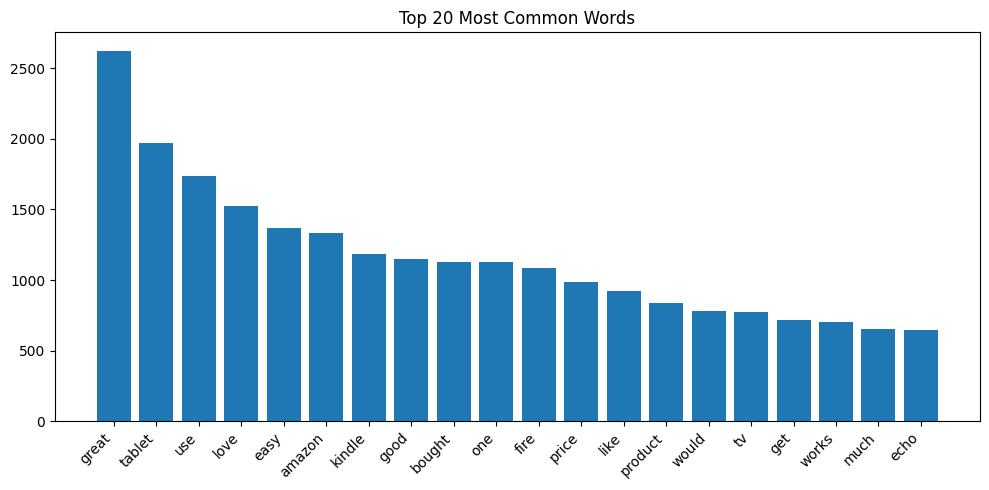

In [32]:
from collections import Counter
import matplotlib.pyplot as plt

all_words = [word for tokens in df['cleaned_tokens'] for word in tokens]
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)
plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Common Words')
plt.tight_layout()
plt.show()

### sentiment class distribution chart

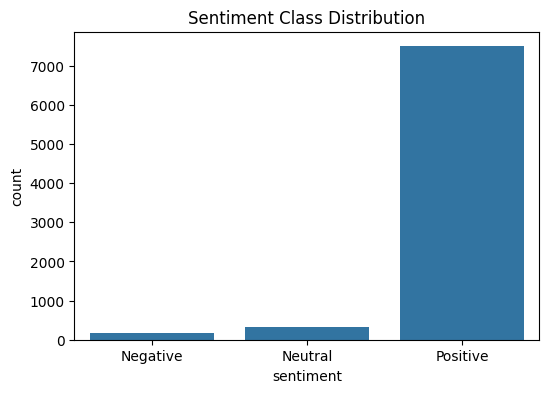

In [33]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, order=['Negative','Neutral','Positive'])
plt.title('Sentiment Class Distribution')
plt.show()

### TF-IDF Vectorization

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_text'])
y = df['sentiment']

TF-IDF
TF-IDF (Term Frequency–Inverse Document Frequency) was chosen because it weighs words by how important they are to a specific review relative to the whole dataset — common words like "the" or "good" that appear everywhere get down-weighted, while distinctive words that signal sentiment get more weight. It's simple, fast, and works well for a classical ML model like Logistic Regression, without needing the heavier setup that word embeddings require.

### Train/test split + train  classifier

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Evaluation

In [37]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.9375
Precision: 0.8990734649122807
Recall: 0.9375
F1-Score: 0.9089500950882026


C:\Users\USER\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


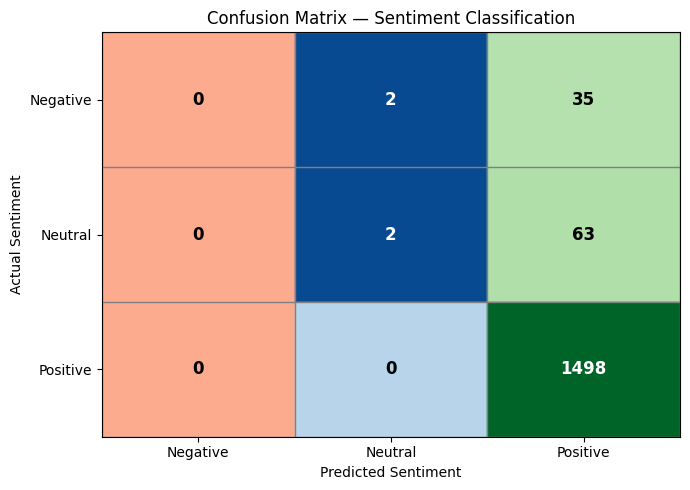

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix

labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)

col_colors = {
    'Negative': 'Reds',
    'Neutral': 'Blues',
    'Positive': 'Greens'
}

fig, ax = plt.subplots(figsize=(7,5))

cm_norm = cm.astype(float)
for j in range(cm.shape[1]):
    col_max = cm[:, j].max() if cm[:, j].max() > 0 else 1
    cm_norm[:, j] = cm[:, j] / col_max

for j, label in enumerate(labels):
    cmap = plt.get_cmap(col_colors[label])
    for i in range(cm.shape[0]):
        color = cmap(0.3 + 0.6 * cm_norm[i, j])  # keep shades readable, not too pale/dark
        ax.add_patch(plt.Rectangle((j, i), 1, 1, color=color))
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm_norm[i, j] > 0.5 else 'black', fontsize=12, fontweight='bold')

ax.set_xlim(0, len(labels))
ax.set_ylim(0, len(labels))
ax.invert_yaxis()
ax.set_xticks(np.arange(len(labels)) + 0.5)
ax.set_yticks(np.arange(len(labels)) + 0.5)
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted Sentiment')
ax.set_ylabel('Actual Sentiment')
ax.set_title('Confusion Matrix — Sentiment Classification')

ax.set_xticks(np.arange(len(labels)+1), minor=True)
ax.set_yticks(np.arange(len(labels)+1), minor=True)
ax.grid(which='minor', color='grey', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
plt.show()
